# Steam Game Market Intelligence (ML + Statistical Analysis)

**Dataset:** Steam Games Dataset, about 130K titles with prices, genres, tags, platforms, reviews, playtime and owner estimates.

**Goal:** turn raw store metadata into decisions a studio, publisher or investor could act on: where the market is crowded, what separates games that get traction from those that don't, and which segments are under-served.

## Contents
1. Setup and configuration
2. Data loading and header repair
3. Data quality audit
4. Feature engineering
5. Market overview
6. Statistical analysis
7. Market intelligence: genre opportunity map
8. Machine learning
   - 8.1 Predicting commercial traction (classification)
   - 8.2 Predicting review sentiment (regression)
   - 8.3 Market segmentation (clustering)
9. Key findings, limitations and next steps

**Method note.** Review counts are used as the measure of traction because owner counts in this file are coarse ranges. Statistical claims are reported with effect sizes and confidence intervals rather than p-values alone, and multiple comparisons are corrected.

## 1. Setup and configuration

In [1]:
import glob
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

BLUE, PURPLE, PINK, TEAL, AMBER = "#1f77d0", "#7a5cff", "#e5508f", "#14b8a6", "#f2a93b"

## 2. Data loading and header repair

The raw `games.csv` header lists **39** column names, but every row contains **40** values: the header has `DiscountDLC count` where the rows have two separate fields, `Discount` and `DLC count`. Loaded naively, every column after `Price` is mislabeled. The cell below supplies the correct 40 names explicitly. It works whether or not the file's own header has already been fixed, because the existing header line is replaced.

In [2]:
COLUMNS = [
    "AppID", "Name", "Release date", "Estimated owners", "Peak CCU", "Required age", "Price",
    "Discount", "DLC count", "About the game", "Supported languages", "Full audio languages",
    "Reviews", "Header image", "Website", "Support url", "Support email", "Windows", "Mac", "Linux",
    "Metacritic score", "Metacritic url", "User score", "Positive", "Negative", "Score rank",
    "Achievements", "Recommendations", "Notes", "Average playtime forever",
    "Average playtime two weeks", "Median playtime forever", "Median playtime two weeks",
    "Developers", "Publishers", "Categories", "Genres", "Tags", "Screenshots", "Movies",
]

def find_games_csv():
    candidates = ["games.csv", "../input/games.csv", "/mnt/user-data/uploads/games.csv"]
    candidates += glob.glob("/kaggle/input/**/games.csv", recursive=True)
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("games.csv not found. Attach the dataset or place the file next to this notebook.")

DATA_PATH = find_games_csv()
df = pd.read_csv(DATA_PATH, header=0, names=COLUMNS)
print(f"Loaded {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df[["AppID", "Name", "Release date", "Estimated owners", "Price", "Discount", "DLC count", "Positive", "Negative"]].head()

Loaded games.csv
Shape: 130,100 rows x 40 columns


,AppID,Name,Release date,Estimated owners,Price,Discount,DLC count,Positive,Negative
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0.000,0,0,0,0
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,5.240,65,0,252,3
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,4.990,0,0,21,3
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,8.990,0,1,0,0
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,4.990,0,0,0,0


## 3. Data quality audit

Before modelling, check what is missing, what is degenerate, and what the zeros mean. Steam contains many playtests, demos and unreleased titles, so zeros are often genuine "no activity" rather than missing data.

Duplicate AppIDs: 0
Repeated names (different AppIDs, e.g. demos, playtests, reissues): 5455


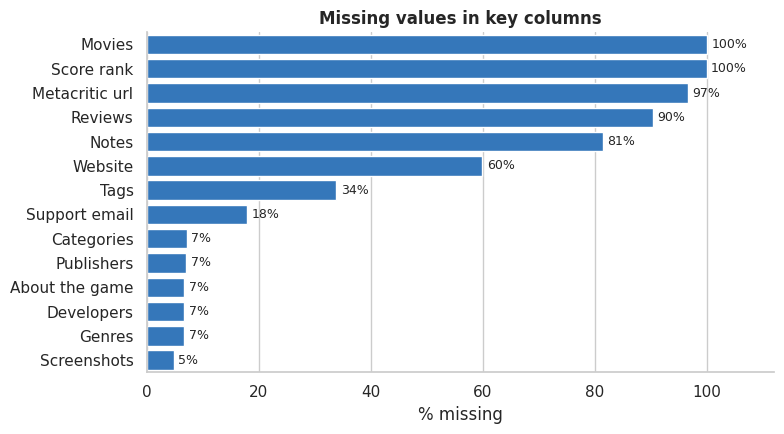

In [3]:
print("Duplicate AppIDs:", df["AppID"].duplicated().sum())
print("Repeated names (different AppIDs, e.g. demos, playtests, reissues):", df["Name"].duplicated().sum())

key_cols = ["About the game", "Reviews", "Website", "Support email", "Metacritic url", "Score rank",
            "Notes", "Developers", "Publishers", "Categories", "Genres", "Tags", "Screenshots", "Movies"]
missing = (df[key_cols].isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=missing.values, y=missing.index, color=BLUE, ax=ax)
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Missing values in key columns")
for i, v in enumerate(missing.values):
    ax.text(v + 0.8, i, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, 112)
plt.tight_layout()
plt.show()

In [4]:
total_reviews = df["Positive"] + df["Negative"]
zero_share = pd.Series({
    "Price = 0 (free)": (df["Price"] == 0).mean(),
    "Zero reviews": (total_reviews == 0).mean(),
    "Owners range '0 - 0'": (df["Estimated owners"] == "0 - 0").mean(),
    "Owners range '0 - 20000'": (df["Estimated owners"] == "0 - 20000").mean(),
    "Metacritic score present": (df["Metacritic score"] > 0).mean(),
    "Required age > 0": (df["Required age"] > 0).mean(),
    "No trailer data (Movies empty)": df["Movies"].isna().mean(),
}) * 100
zero_share.to_frame("% of rows")

,% of rows
Price = 0 (free),21.208
Zero reviews,34.135
Owners range '0 - 0',19.558
Owners range '0 - 20000',60.166
Metacritic score present,3.368
Required age > 0,1.028
No trailer data (Movies empty),100.000


**Reading the audit.** Roughly a third of titles have no reviews at all and most of the rest sit in the lowest owner bucket, so the outcome distribution is extremely zero-inflated. Two consequences shape the rest of the notebook: (1) we model *traction thresholds* and use rank-based tests rather than means, and (2) the `Movies` column is empty and `Score rank` and `Metacritic` are too sparse to use.

## 4. Feature engineering

Raw fields are converted into analysis-ready features: parsed dates, review totals, an approximate owner estimate, counts of languages, tags and screenshots, and indicator variables. Genres and categories are expanded into multi-hot columns.

**Snapshot date.** The file contains games with future release dates. The data snapshot is approximated as the latest release date among titles that already have reviews. Titles released after it are treated as unreleased and excluded from outcome analysis.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

def count_list(s):
    """Count items in a stringified list such as "['English', 'French']"."""
    return s.fillna("[]").str.count("'") // 2

def count_csv(s):
    """Count items in a comma-separated string (0 if empty)."""
    s = s.fillna("")
    return np.where(s.eq(""), 0, s.str.count(",") + 1)

d = df.copy()
d["release_date"] = pd.to_datetime(d["Release date"], format="mixed", errors="coerce")
d["release_year"] = d["release_date"].dt.year
d["release_month"] = d["release_date"].dt.month

d["total_reviews"] = d["Positive"] + d["Negative"]
d["pos_ratio"] = d["Positive"] / d["total_reviews"].replace(0, np.nan)

own = d["Estimated owners"].str.extract(r"(\d+)\s*-\s*(\d+)").astype(float)
d["owners_low"], d["owners_high"] = own[0], own[1]
d["owners_mid"] = (own[0] + own[1]) / 2

d["price"] = d["Price"]
d["is_free"] = (d["Price"] == 0).astype(int)
d["price_bucket"] = pd.cut(
    d["Price"], bins=[-0.01, 0, 2, 5, 10, 20, np.inf],
    labels=["Free", "$0-2", "$2-5", "$5-10", "$10-20", "$20+"],
)

d["n_languages"] = count_list(d["Supported languages"])
d["n_audio"] = count_list(d["Full audio languages"])
d["n_platforms"] = d[["Windows", "Mac", "Linux"]].sum(axis=1)
d["multi_platform"] = ((d["Mac"]) | (d["Linux"])).astype(int)
d["has_website"] = d["Website"].notna().astype(int)
d["has_support_email"] = d["Support email"].notna().astype(int)
d["desc_len"] = d["About the game"].fillna("").str.len()
d["n_screenshots"] = count_csv(d["Screenshots"])
d["n_genres"] = count_csv(d["Genres"])
# Category count excludes "Steam Trading Cards": Valve enables cards after a game shows sales traction,
# so including it would leak the outcome into a launch-time feature.
d["n_categories"] = d["Categories"].fillna("").map(
    lambda s: sum(1 for t in s.split(",") if t.strip() and "Trading Cards" not in t)
)
d["n_tags"] = count_csv(d["Tags"])
d["age_restricted"] = (d["Required age"] > 0).astype(int)

SNAPSHOT = d.loc[d["total_reviews"] > 0, "release_date"].max()
d["released"] = d["release_date"] <= SNAPSHOT
print("Approximate data snapshot:", SNAPSHOT.date())
print("Titles with a future release date:", (~d["released"]).sum())

def multi_hot(series, top_n, prefix):
    cv = CountVectorizer(
        tokenizer=lambda s: [t.strip() for t in s.split(",") if t.strip()],
        lowercase=False, binary=True, max_features=top_n, token_pattern=None,
    )
    m = cv.fit_transform(series.fillna(""))
    names = [f"{prefix}_{t}" for t in cv.get_feature_names_out()]
    return pd.DataFrame(m.toarray().astype(np.int8), columns=names, index=series.index)

genre_df = multi_hot(d["Genres"], 22, "genre")
cat_df = multi_hot(d["Categories"], 20, "cat")
tag_df = multi_hot(d["Tags"], 100, "tag")
GENRE_COLS, CAT_COLS, TAG_COLS = list(genre_df.columns), list(cat_df.columns), list(tag_df.columns)
d = pd.concat([d, genre_df, cat_df, tag_df], axis=1)

# Commercial-traction label: 100+ Steam reviews
HIT_THRESHOLD = 100
d["hit"] = (d["total_reviews"] >= HIT_THRESHOLD).astype(int)

released = d[d["released"]].copy()
print(f"Released titles: {len(released):,} | hit rate (>= {HIT_THRESHOLD} reviews): {released['hit'].mean():.1%}")

Approximate data snapshot: 2025-12-25
Titles with a future release date: 3628


Released titles: 126,472 | hit rate (>= 100 reviews): 18.6%


## 5. Market overview

### 5.1 Supply growth, pricing and free-to-play share

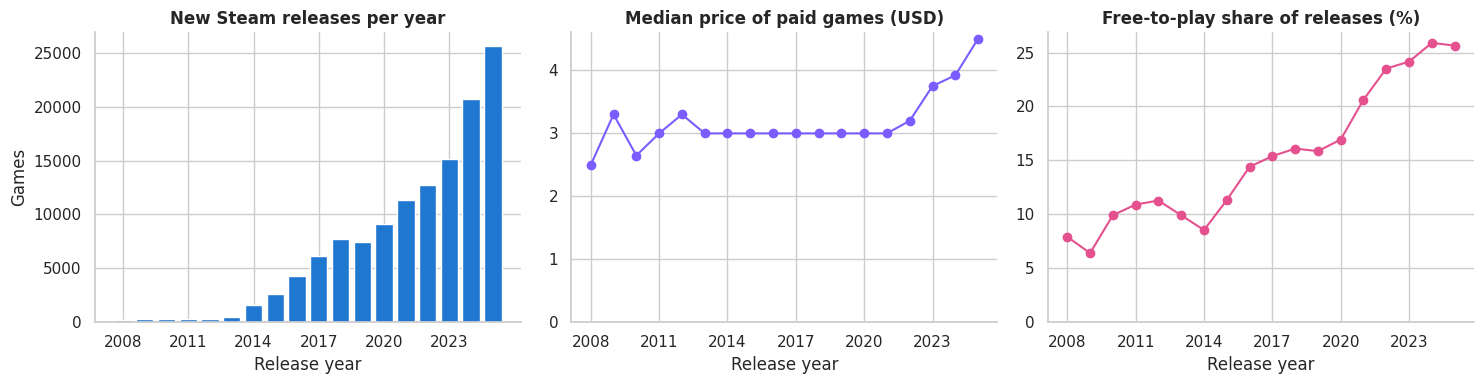

,games,median_price_paid,free_share
release_year,,,
2020,9093,2.990,0.169
2021,11389,2.990,0.206
2022,12694,3.190,0.235
2023,15112,3.740,0.242
2024,20750,3.910,0.259
2025,25625,4.490,0.256


In [6]:
yearly = (
    released[released["release_year"].between(2008, 2025)]
    .groupby("release_year")
    .agg(games=("AppID", "size"),
         median_price_paid=("price", lambda s: s[s > 0].median()),
         free_share=("is_free", "mean"))
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(yearly.index, yearly["games"], color=BLUE)
axes[0].set_title("New Steam releases per year")
axes[0].set_ylabel("Games")

axes[1].plot(yearly.index, yearly["median_price_paid"], marker="o", color=PURPLE)
axes[1].set_title("Median price of paid games (USD)")
axes[1].set_ylim(0, None)

axes[2].plot(yearly.index, yearly["free_share"] * 100, marker="o", color=PINK)
axes[2].set_title("Free-to-play share of releases (%)")
axes[2].set_ylim(0, None)
for ax in axes:
    ax.set_xlabel("Release year")
    ax.set_xticks(range(2008, 2026, 3))
plt.tight_layout()
plt.show()

yearly.tail(6)

### 5.2 Price distribution and genre mix

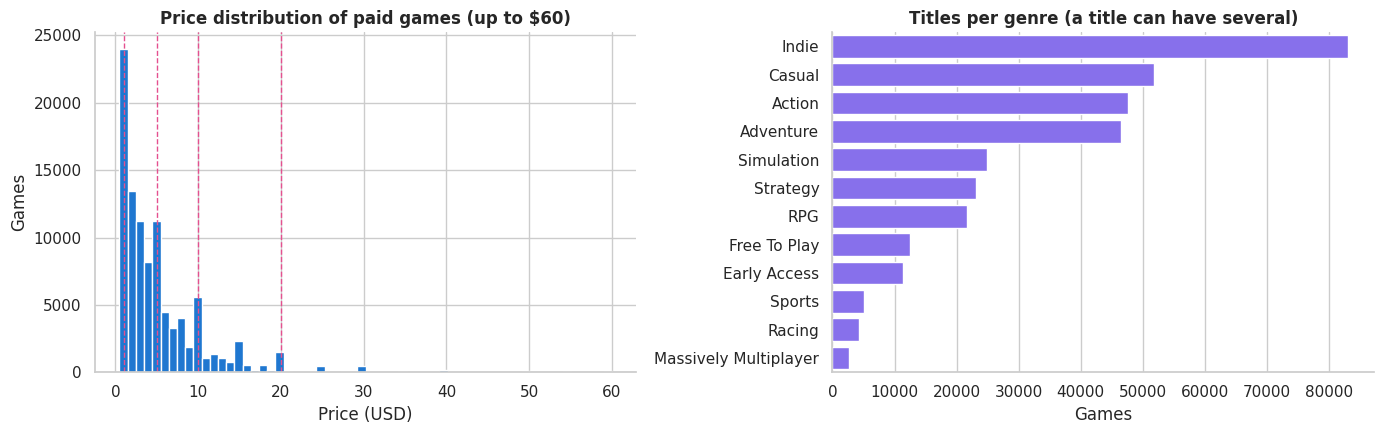

,% of paid games
price,
0.990,9.284
4.990,8.424
1.990,6.897
2.990,6.566
9.990,4.817
3.990,4.741
0.490,3.779
5.990,3.234


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

paid = released.loc[(released["price"] > 0) & (released["price"] <= 60), "price"]
axes[0].hist(paid, bins=60, color=BLUE, edgecolor="white")
axes[0].set_title("Price distribution of paid games (up to $60)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Games")
for p in (0.99, 4.99, 9.99, 19.99):
    axes[0].axvline(p, color=PINK, ls="--", lw=1)

genre_counts = released[[c for c in GENRE_COLS]].sum().sort_values(ascending=False).head(12)
genre_counts.index = [i.replace("genre_", "") for i in genre_counts.index]
sns.barplot(x=genre_counts.values, y=genre_counts.index, color=PURPLE, ax=axes[1])
axes[1].set_title("Titles per genre (a title can have several)")
axes[1].set_xlabel("Games")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

top_price_points = released.loc[released["price"] > 0, "price"].round(2).value_counts(normalize=True).head(8) * 100
top_price_points.rename("% of paid games").to_frame()

**Takeaway.** Supply has grown several-fold since 2014 while pricing has stayed anchored to a handful of price points ($0.99, $4.99, $9.99, $19.99). The market is crowded and price-point driven, so discoverability, not production, is the scarce resource.

## 6. Statistical analysis

To avoid comparing games with very different time to accumulate reviews, the hypothesis tests below use a **mature cohort**: titles released 2014-2022, which have had at least three years of exposure before the snapshot.

In [8]:
mature = released[released["release_year"].between(2014, 2022)].copy()
rated = mature[mature["total_reviews"] >= 50].copy()   # enough votes for a stable positive ratio
print(f"Mature cohort: {len(mature):,} titles | with >= 50 reviews (rated): {len(rated):,}")

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half

Mature cohort: 62,950 titles | with >= 50 reviews (rated): 22,109


### 6.1 Correlation structure (Spearman)

Rank correlation is used because every outcome is heavily skewed and zero-inflated.

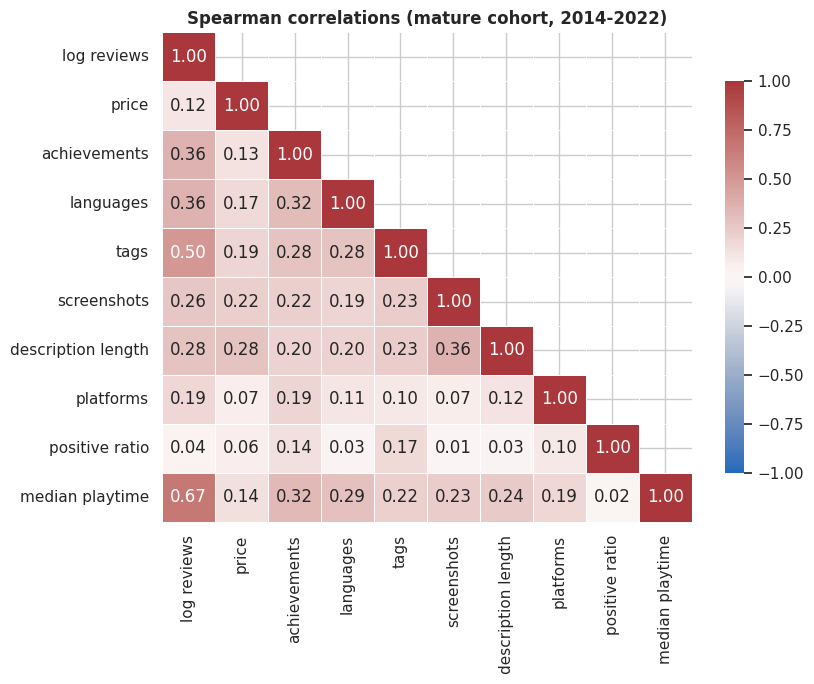

In [9]:
corr_cols = {
    "log reviews": np.log1p(mature["total_reviews"]),
    "price": mature["price"],
    "achievements": mature["Achievements"],
    "languages": mature["n_languages"],
    "tags": mature["n_tags"],
    "screenshots": mature["n_screenshots"],
    "description length": mature["desc_len"],
    "platforms": mature["n_platforms"],
    "positive ratio": mature["pos_ratio"],
    "median playtime": mature["Median playtime forever"],
}
corr = pd.DataFrame(corr_cols).corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Spearman correlations (mature cohort, 2014-2022)")
plt.tight_layout()
plt.show()

### 6.2 Do free games earn more reviews, and are they liked more?

Mann-Whitney U tests compare free and paid titles. The effect size is the **probability of superiority**: the chance that a randomly chosen free game beats a randomly chosen paid game (0.5 means no difference). A bootstrap interval is given for the difference in median positive ratio.

,metric,n_free,n_paid,median_free,median_paid,prob_superiority_free,p_value
0,total reviews (all mature titles),11291,51659,16.000,22.000,0.421,0.000
1,positive ratio (>= 50 reviews),3612,18497,0.787,0.807,0.467,0.000


Median positive-ratio difference (free minus paid): -0.020  95% bootstrap CI [-0.028, -0.012]


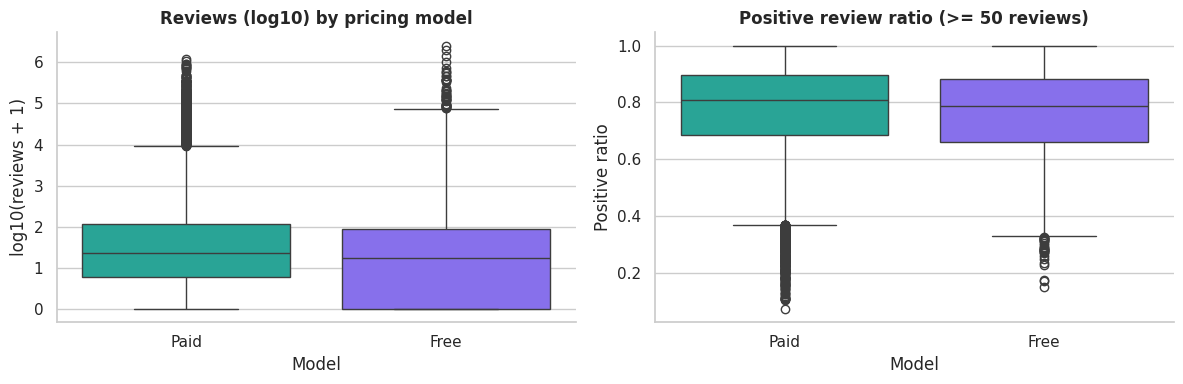

In [10]:
def mannwhitney_report(a, b, label):
    a, b = a.dropna(), b.dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    ps = u / (len(a) * len(b))
    return {"metric": label, "n_free": len(a), "n_paid": len(b),
            "median_free": a.median(), "median_paid": b.median(),
            "prob_superiority_free": ps, "p_value": p}

free, paid_ = mature[mature["is_free"] == 1], mature[mature["is_free"] == 0]
free_r, paid_r = rated[rated["is_free"] == 1], rated[rated["is_free"] == 0]

res = pd.DataFrame([
    mannwhitney_report(free["total_reviews"], paid_["total_reviews"], "total reviews (all mature titles)"),
    mannwhitney_report(free_r["pos_ratio"], paid_r["pos_ratio"], "positive ratio (>= 50 reviews)"),
])
display(res)

def boot_median_diff(a, b, n_boot=1000):
    a, b = a.dropna().values, b.dropna().values
    diffs = [np.median(rng.choice(a, len(a))) - np.median(rng.choice(b, len(b))) for _ in range(n_boot)]
    return np.percentile(diffs, [2.5, 97.5])

lo, hi = boot_median_diff(free_r["pos_ratio"], paid_r["pos_ratio"])
print(f"Median positive-ratio difference (free minus paid): "
      f"{free_r['pos_ratio'].median() - paid_r['pos_ratio'].median():+.3f}  95% bootstrap CI [{lo:+.3f}, {hi:+.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=mature.assign(Model=np.where(mature["is_free"] == 1, "Free", "Paid"),
                               log_reviews=np.log10(mature["total_reviews"] + 1)),
            x="Model", y="log_reviews", palette=[TEAL, PURPLE], ax=axes[0])
axes[0].set_title("Reviews (log10) by pricing model")
axes[0].set_ylabel("log10(reviews + 1)")
sns.boxplot(data=rated.assign(Model=np.where(rated["is_free"] == 1, "Free", "Paid")),
            x="Model", y="pos_ratio", palette=[TEAL, PURPLE], ax=axes[1])
axes[1].set_title("Positive review ratio (>= 50 reviews)")
axes[1].set_ylabel("Positive ratio")
plt.tight_layout()
plt.show()

### 6.3 Price bands: sentiment and traction

A Kruskal-Wallis test checks whether positive ratio differs across price bands. The effect size is epsilon-squared (share of rank variance explained by the band). Traction is shown as the hit rate with Wilson 95% intervals.

Kruskal-Wallis H = 591.8, p = 1.20e-125, epsilon^2 = 0.027


,titles,hits,hit_rate,ci_low,ci_high,median_pos_ratio
price_bucket,,,,,,
Free,11291,2655,0.235,0.227,0.243,0.787
$0-2,20844,4491,0.215,0.210,0.221,0.767
$2-5,15998,4330,0.271,0.264,0.278,0.824
$5-10,9338,2802,0.300,0.291,0.309,0.835
$10-20,4489,1670,0.372,0.358,0.386,0.825
$20+,990,377,0.381,0.351,0.411,0.804


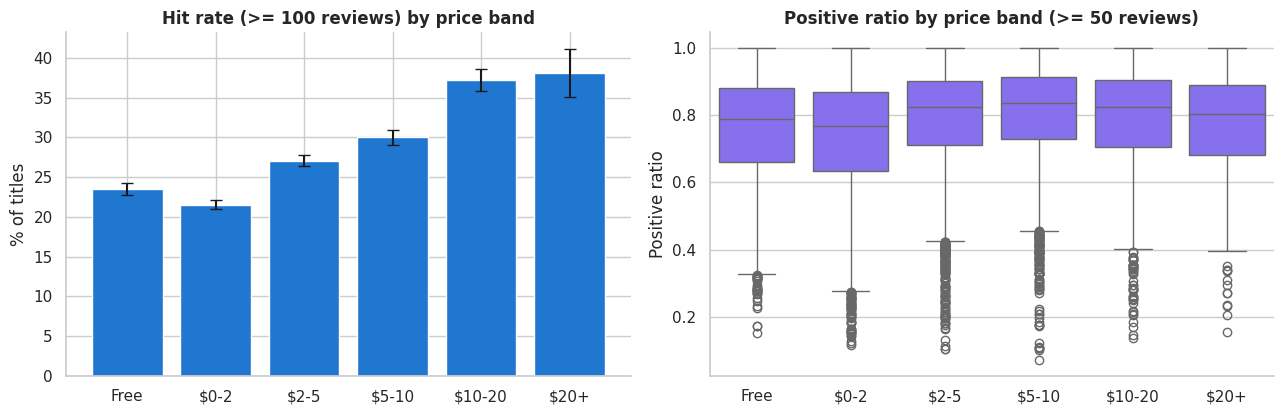

In [11]:
bucket_order = ["Free", "$0-2", "$2-5", "$5-10", "$10-20", "$20+"]
groups = [rated.loc[rated["price_bucket"] == b, "pos_ratio"].dropna() for b in bucket_order]
H, p_kw = stats.kruskal(*groups)
n_tot, k = sum(len(g) for g in groups), len(groups)
eps2 = (H - k + 1) / (n_tot - k)
print(f"Kruskal-Wallis H = {H:,.1f}, p = {p_kw:.2e}, epsilon^2 = {eps2:.3f}")

band = (mature.groupby("price_bucket", observed=True)
        .agg(titles=("hit", "size"), hits=("hit", "sum"), hit_rate=("hit", "mean"))
        .reindex(bucket_order))
band["ci_low"], band["ci_high"] = zip(*[wilson_ci(h, n) for h, n in zip(band["hits"], band["titles"])])
band["median_pos_ratio"] = [g.median() for g in groups]
display(band)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
x = np.arange(len(bucket_order))
axes[0].bar(x, band["hit_rate"] * 100, color=BLUE,
            yerr=[(band["hit_rate"] - band["ci_low"]) * 100, (band["ci_high"] - band["hit_rate"]) * 100],
            capsize=4)
axes[0].set_xticks(x, bucket_order)
axes[0].set_title(f"Hit rate (>= {HIT_THRESHOLD} reviews) by price band")
axes[0].set_ylabel("% of titles")

sns.boxplot(data=rated, x="price_bucket", y="pos_ratio", order=bucket_order, color=PURPLE, ax=axes[1])
axes[1].set_title("Positive ratio by price band (>= 50 reviews)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Positive ratio")
plt.tight_layout()
plt.show()

### 6.4 Platform reach: does supporting Mac or Linux go with higher traction?

A 2x2 chi-square test with an odds ratio and Wald interval. This is an association, not a causal effect: studios that port to more platforms may also be larger or better funded.

In [12]:
tab = pd.crosstab(mature["multi_platform"], mature["hit"])
chi2, p_chi, _, _ = stats.chi2_contingency(tab)
a, b = tab.loc[1, 1], tab.loc[1, 0]     # multi-platform: hit / not hit
c, dd = tab.loc[0, 1], tab.loc[0, 0]    # Windows-only
odds_ratio = (a * dd) / (b * c)
se = np.sqrt(1 / a + 1 / b + 1 / c + 1 / dd)
ci = np.exp(np.log(odds_ratio) + np.array([-1.96, 1.96]) * se)

rate = mature.groupby("multi_platform")["hit"].mean() * 100
print(f"Hit rate: Windows-only {rate[0]:.1f}% vs Mac/Linux supported {rate[1]:.1f}%")
print(f"Odds ratio = {odds_ratio:.2f}  (95% CI {ci[0]:.2f} to {ci[1]:.2f}),  chi-square p = {p_chi:.2e}")

Hit rate: Windows-only 22.2% vs Mac/Linux supported 37.5%
Odds ratio = 2.10  (95% CI 2.02 to 2.18),  chi-square p = 8.20e-308


### 6.5 Which genres over- or under-perform? (with false-discovery control)

For each genre, hit rate is compared with all other titles using a chi-square test. Because many genres are tested at once, p-values are adjusted with the Benjamini-Hochberg procedure.

,genre,titles,hit_rate,ci_low,ci_high,lift_vs_rest,p_value,p_adj_BH,significant
0,Massively Multiplayer,1417,0.432,0.406,0.458,1.691,0.000,0.000,True
1,Free To Play,5206,0.354,0.341,0.367,1.411,0.000,0.000,True
2,RPG,10581,0.338,0.329,0.347,1.390,0.000,0.000,True
3,Simulation,12086,0.318,0.310,0.326,1.296,0.000,0.000,True
4,Strategy,11582,0.298,0.290,0.306,1.189,0.000,0.000,True
5,Adventure,24238,0.295,0.289,0.301,1.243,0.000,0.000,True
6,Racing,2198,0.272,0.254,0.291,1.051,0.173,0.210,False
7,Action,25592,0.268,0.263,0.273,1.057,0.000,0.000,True
8,Sports,2821,0.262,0.246,0.279,1.011,0.761,0.761,False
9,Indie,44174,0.256,0.252,0.260,0.961,0.007,0.010,True


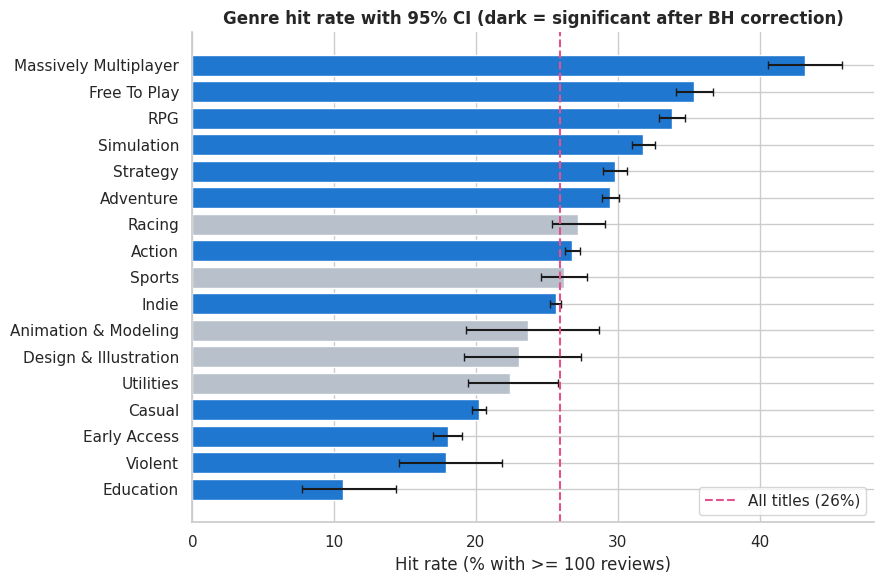

In [13]:
rows = []
for col in GENRE_COLS:
    g = mature[col] == 1
    n1, n0 = g.sum(), (~g).sum()
    if n1 < 300:
        continue
    k1, k0 = mature.loc[g, "hit"].sum(), mature.loc[~g, "hit"].sum()
    _, p, _, _ = stats.chi2_contingency([[k1, n1 - k1], [k0, n0 - k0]])
    lo_, hi_ = wilson_ci(k1, n1)
    rows.append({"genre": col.replace("genre_", ""), "titles": n1, "hit_rate": k1 / n1,
                 "ci_low": lo_, "ci_high": hi_, "lift_vs_rest": (k1 / n1) / (k0 / n0), "p_value": p})

genre_tests = pd.DataFrame(rows)
genre_tests["p_adj_BH"] = stats.false_discovery_control(genre_tests["p_value"].values, method="bh")
genre_tests["significant"] = genre_tests["p_adj_BH"] < 0.05
genre_tests = genre_tests.sort_values("hit_rate", ascending=False).reset_index(drop=True)
display(genre_tests)

base = mature["hit"].mean()
fig, ax = plt.subplots(figsize=(9, 6))
colors = np.where(genre_tests["significant"], BLUE, "#b8c0cc")
ax.barh(genre_tests["genre"], genre_tests["hit_rate"] * 100, color=colors,
        xerr=[(genre_tests["hit_rate"] - genre_tests["ci_low"]) * 100,
              (genre_tests["ci_high"] - genre_tests["hit_rate"]) * 100], capsize=3)
ax.axvline(base * 100, color=PINK, ls="--", label=f"All titles ({base:.0%})")
ax.invert_yaxis()
ax.set_xlabel("Hit rate (% with >= 100 reviews)")
ax.set_title("Genre hit rate with 95% CI (dark = significant after BH correction)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.6 Winner-take-most: concentration of attention

A Lorenz curve and Gini coefficient measure how unequally reviews are distributed across games.

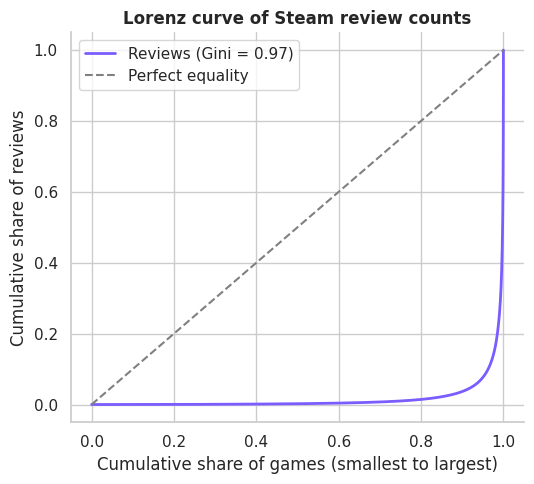

Gini coefficient (games with >= 1 review): 0.967
Top 1% of games hold 74.9% of all reviews; top 10% hold 96.3%.


In [14]:
rev = np.sort(released.loc[released["total_reviews"] > 0, "total_reviews"].values)
cum = np.cumsum(rev) / rev.sum()
x_ = np.arange(1, len(rev) + 1) / len(rev)
trap = getattr(np, "trapezoid", None) or np.trapz
gini = 1 - 2 * trap(cum, x_)

def top_share(frac):
    n_top = int(np.ceil(len(rev) * frac))
    return rev[-n_top:].sum() / rev.sum()

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(x_, cum, color=PURPLE, lw=2, label=f"Reviews (Gini = {gini:.2f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", label="Perfect equality")
ax.set_xlabel("Cumulative share of games (smallest to largest)")
ax.set_ylabel("Cumulative share of reviews")
ax.set_title("Lorenz curve of Steam review counts")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Gini coefficient (games with >= 1 review): {gini:.3f}")
print(f"Top 1% of games hold {top_share(0.01):.1%} of all reviews; top 10% hold {top_share(0.10):.1%}.")

### 6.7 Does launch month matter?

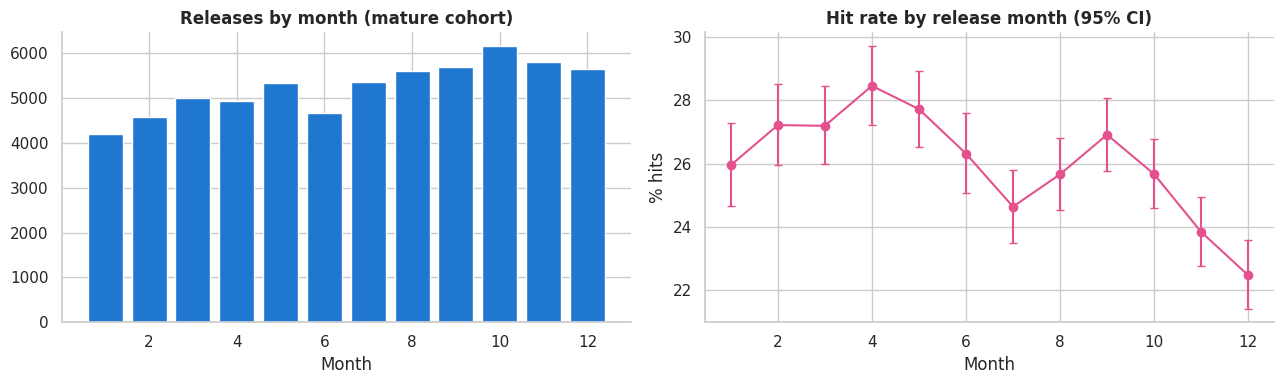

Chi-square across months: p = 1.56e-14, Cramer's V = 0.038


In [15]:
mon = (mature.groupby("release_month")
       .agg(titles=("hit", "size"), hits=("hit", "sum"), hit_rate=("hit", "mean")))
mon["ci_low"], mon["ci_high"] = zip(*[wilson_ci(h, n) for h, n in zip(mon["hits"], mon["titles"])])
chi2_m, p_m, _, _ = stats.chi2_contingency(np.c_[mon["hits"], mon["titles"] - mon["hits"]])
cramers_v = np.sqrt(chi2_m / (mon["titles"].sum() * 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(mon.index, mon["titles"], color=BLUE)
axes[0].set_title("Releases by month (mature cohort)")
axes[0].set_xlabel("Month")
axes[1].errorbar(mon.index, mon["hit_rate"] * 100,
                 yerr=[(mon["hit_rate"] - mon["ci_low"]) * 100, (mon["ci_high"] - mon["hit_rate"]) * 100],
                 fmt="o-", color=PINK, capsize=3)
axes[1].set_title("Hit rate by release month (95% CI)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("% hits")
plt.tight_layout()
plt.show()
print(f"Chi-square across months: p = {p_m:.2e}, Cramer's V = {cramers_v:.3f}")

## 7. Market intelligence: genre opportunity map

For each genre, **supply** is its share of releases and **demand** is its share of all reviews (a proxy for player engagement). A ratio above 1 means the genre attracts more attention than its share of releases would suggest. The window is 2018-2022 so every title has had time to collect reviews.

Because review counts are heavy-tailed, a handful of mega-hits can dominate a genre's demand share. Read the ratio alongside the hit rate and median reviews in the table.

,genre,titles,supply_share,demand_share,hit_rate,median_price_paid,median_reviews,demand_to_supply
0,Massively Multiplayer,1096,0.023,0.131,0.356,4.990,35.000,5.795
1,Action,19235,0.398,0.649,0.204,2.990,15.000,1.634
2,RPG,8327,0.172,0.254,0.279,3.990,20.000,1.477
3,Adventure,18720,0.387,0.459,0.233,2.990,19.000,1.186
4,Sports,2124,0.044,0.051,0.216,3.890,18.000,1.161
5,Simulation,9413,0.195,0.202,0.267,3.890,22.000,1.038
6,Strategy,8763,0.181,0.166,0.231,3.740,18.000,0.918
7,Racing,1695,0.035,0.030,0.217,2.990,17.000,0.848
8,Indie,33992,0.703,0.463,0.197,2.990,16.000,0.658
9,Casual,20865,0.431,0.184,0.152,2.000,12.000,0.426


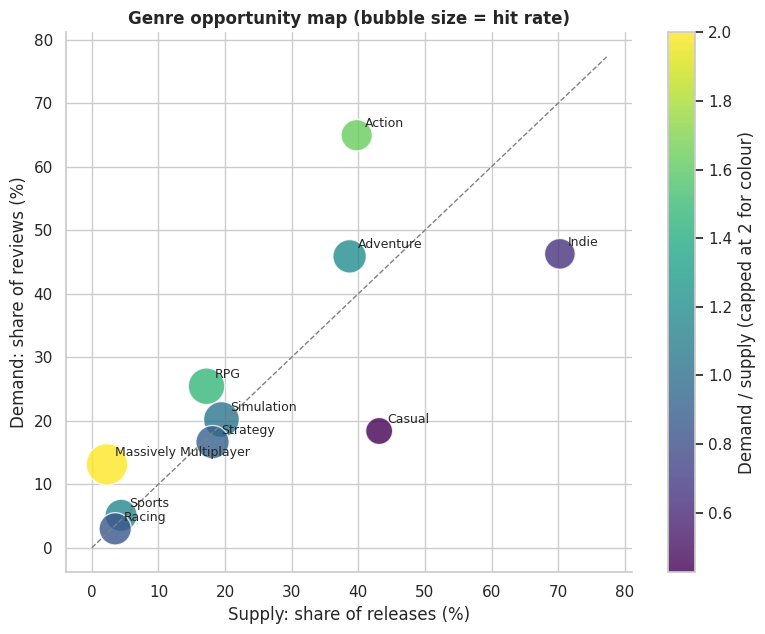

In [16]:
window = released[released["release_year"].between(2018, 2022)]
skip = {"genre_Free To Play", "genre_Early Access", "genre_Utilities", "genre_Design & Illustration",
        "genre_Animation & Modeling", "genre_Video Production", "genre_Audio Production",
        "genre_Software Training", "genre_Web Publishing", "genre_Photo Editing",
        "genre_Education", "genre_Game Development", "genre_Accounting", "genre_No Genre"}
opp = []
for col in GENRE_COLS:
    if col in skip:
        continue
    g = window[col] == 1
    if g.sum() < 300:
        continue
    paid_g = window.loc[g & (window["price"] > 0), "price"]
    opp.append({
        "genre": col.replace("genre_", ""),
        "titles": int(g.sum()),
        "supply_share": g.mean(),
        "demand_share": window.loc[g, "total_reviews"].sum() / window["total_reviews"].sum(),
        "hit_rate": window.loc[g, "hit"].mean(),
        "median_price_paid": paid_g.median(),
        "median_reviews": window.loc[g, "total_reviews"].median(),
    })
opp = pd.DataFrame(opp)
opp["demand_to_supply"] = opp["demand_share"] / opp["supply_share"]
opp = opp.sort_values("demand_to_supply", ascending=False).reset_index(drop=True)
display(opp)

fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(opp["supply_share"] * 100, opp["demand_share"] * 100, s=opp["hit_rate"] * 2500,
                c=np.clip(opp["demand_to_supply"], 0.4, 2.0), cmap="viridis", alpha=0.8, edgecolor="white")
lim = max(opp["supply_share"].max(), opp["demand_share"].max()) * 100 * 1.1
ax.plot([0, lim], [0, lim], color="grey", ls="--", lw=1)
for _, r in opp.iterrows():
    ax.annotate(r["genre"], (r["supply_share"] * 100, r["demand_share"] * 100),
                xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_xlabel("Supply: share of releases (%)")
ax.set_ylabel("Demand: share of reviews (%)")
ax.set_title("Genre opportunity map (bubble size = hit rate)")
plt.colorbar(sc, label="Demand / supply (capped at 2 for colour)")
plt.tight_layout()
plt.show()

## 8. Machine learning

### 8.1 Predicting commercial traction (classification)

**Task.** Predict whether a game reaches 100+ reviews, using only information a studio would know around launch.

**Leakage control.**
- Excluded: reviews, recommendations, peak concurrent users, playtime, owner estimates, Metacritic and user scores, DLC count. These are outcomes or accumulate after release.
- The **Steam Trading Cards** category is also excluded: Valve typically enables cards only after a game has shown sales traction, so it encodes success rather than predicting it. It is also left out of the category count.
- Genres and the remaining categories are used as the launch-time feature set. User-defined **tags** accumulate after release, so they are tested separately as an ablation.
- **Time-based split:** train on 2014-2020 releases, test on 2021-2022. Later years are excluded because they have not had time to collect reviews, which would bias the label.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (average_precision_score, mean_absolute_error, mean_squared_error,
                             precision_recall_curve, r2_score, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

SKEWED = ["price", "Achievements", "n_languages", "n_audio", "desc_len", "n_screenshots"]
PLAIN = ["is_free", "age_restricted", "Windows", "Mac", "Linux", "n_platforms", "has_website",
         "has_support_email", "n_genres", "n_categories", "release_month"]
for c in ("Windows", "Mac", "Linux"):
    d[c] = d[c].astype(int)
    released[c] = released[c].astype(int)

LAUNCH_CATS = [c for c in CAT_COLS if "Trading Cards" not in c]
BASE_FEATURES = SKEWED + PLAIN + GENRE_COLS + LAUNCH_CATS
TAG_FEATURES = BASE_FEATURES + TAG_COLS + ["n_tags"]

model_df = released[released["release_year"].between(2014, 2022)].copy()
train = model_df[model_df["release_year"] <= 2020]
test = model_df[model_df["release_year"] >= 2021]
print(f"Train: {len(train):,} titles ({train['hit'].mean():.1%} hits) | Test: {len(test):,} titles ({test['hit'].mean():.1%} hits)")

def make_logreg(features):
    pre = ColumnTransformer([
        ("skewed", Pipeline([("log", FunctionTransformer(np.log1p)), ("sc", StandardScaler())]),
         [f for f in features if f in SKEWED]),
        ("rest", StandardScaler(), [f for f in features if f not in SKEWED]),
    ])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, C=0.3))])

def make_hgb(**kw):
    return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_leaf_nodes=31,
                                          l2_regularization=1.0, early_stopping=True,
                                          validation_fraction=0.15, random_state=RANDOM_STATE, **kw)

experiments = {
    "Logistic regression (launch features)": (make_logreg(BASE_FEATURES), BASE_FEATURES),
    "Gradient boosting (launch features)": (make_hgb(), BASE_FEATURES),
    "Gradient boosting (+ tags, post-launch)": (make_hgb(), TAG_FEATURES),
}

results, fitted, curves = [], {}, {}
y_train, y_test = train["hit"].values, test["hit"].values
for name, (model, feats) in experiments.items():
    model.fit(train[feats], y_train)
    proba = model.predict_proba(test[feats])[:, 1]
    top10 = proba >= np.quantile(proba, 0.9)
    results.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "precision @ top 10%": y_test[top10].mean(),
        "lift @ top 10%": y_test[top10].mean() / y_test.mean(),
    })
    fitted[name] = (model, feats)
    curves[name] = (roc_curve(y_test, proba), precision_recall_curve(y_test, proba))

results = pd.DataFrame(results).set_index("model")
print(f"Test prevalence (no-skill PR-AUC baseline): {y_test.mean():.3f}")
results

Train: 38,867 titles (32.4% hits) | Test: 24,083 titles (15.4% hits)


Test prevalence (no-skill PR-AUC baseline): 0.154


,ROC-AUC,PR-AUC,precision @ top 10%,lift @ top 10%
model,,,,
Logistic regression (launch features),0.814,0.471,0.544,3.526
Gradient boosting (launch features),0.841,0.569,0.646,4.188
"Gradient boosting (+ tags, post-launch)",0.907,0.704,0.752,4.877


**Reading the table.** The test hit rate (about 15%) is far below the training hit rate (about 32%): the market got more crowded, and the newest test years have had less time to collect reviews. Absolute precision therefore cannot be compared across eras, but ranking metrics (ROC-AUC, lift) remain meaningful because they measure how well games are ordered within the test period. Lift at 10% is the factor by which the top-scored decile beats the base rate.

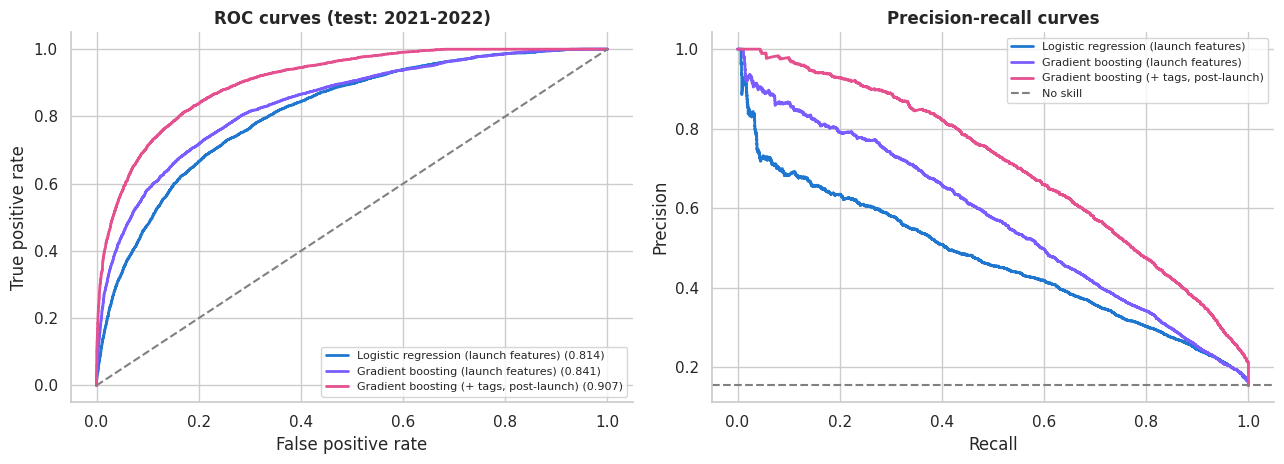

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
palette = [BLUE, PURPLE, PINK]
for (name, ((fpr, tpr, _), (prec, rec, _))), colr in zip(curves.items(), palette):
    axes[0].plot(fpr, tpr, color=colr, lw=2, label=f"{name} ({results.loc[name, 'ROC-AUC']:.3f})")
    axes[1].plot(rec, prec, color=colr, lw=2, label=name)
axes[0].plot([0, 1], [0, 1], color="grey", ls="--")
axes[0].set_title("ROC curves (test: 2021-2022)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].axhline(y_test.mean(), color="grey", ls="--", label="No skill")
axes[1].set_title("Precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Which launch features matter?

Permutation importance on the held-out set: how much does ROC-AUC fall when one feature is shuffled? This is more reliable than built-in importances for boosted trees with correlated, mixed-type inputs.

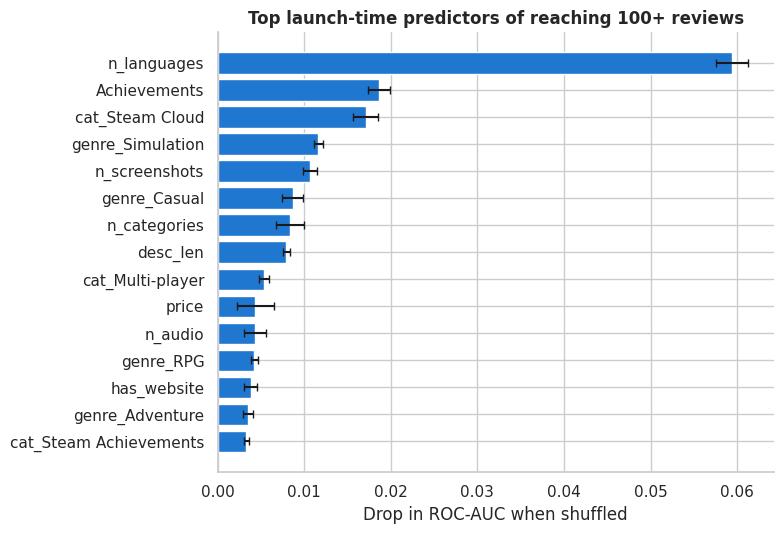

,feature,auc_drop,sd
0,n_languages,0.059,0.002
1,Achievements,0.019,0.001
2,cat_Steam Cloud,0.017,0.001
3,genre_Simulation,0.012,0.000
4,n_screenshots,0.011,0.001
5,genre_Casual,0.009,0.001
6,n_categories,0.008,0.002
7,desc_len,0.008,0.000
8,cat_Multi-player,0.005,0.001
9,price,0.004,0.002


In [19]:
model, feats = fitted["Gradient boosting (launch features)"]
sample = test.sample(min(6000, len(test)), random_state=RANDOM_STATE)
pi = permutation_importance(model, sample[feats], sample["hit"], scoring="roc_auc",
                            n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
imp = (pd.DataFrame({"feature": feats, "auc_drop": pi.importances_mean, "sd": pi.importances_std})
       .sort_values("auc_drop", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(imp["feature"], imp["auc_drop"], xerr=imp["sd"], color=BLUE, capsize=3)
ax.invert_yaxis()
ax.set_xlabel("Drop in ROC-AUC when shuffled")
ax.set_title("Top launch-time predictors of reaching 100+ reviews")
plt.tight_layout()
plt.show()
imp.reset_index(drop=True)

### 8.2 Predicting review sentiment (regression)

**Task.** Among games with at least 50 reviews, predict the positive-review ratio from launch-time features. The same time-based split and leakage rules apply. A mean predictor and a regularised linear model provide the baselines.

Train: 16,964 | Test: 5,145
Mean positive ratio: train 0.758 vs test 0.813


,MAE,RMSE,R2
model,,,
Mean predictor (baseline),0.125,0.147,-0.161
Ridge regression,0.117,0.141,-0.077
Gradient boosting,0.112,0.137,-0.015


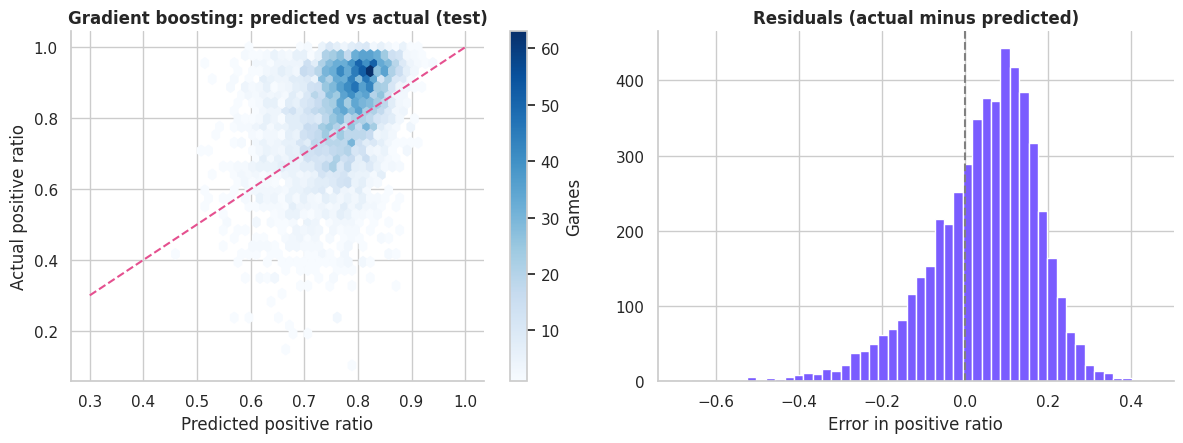

In [20]:
reg_df = model_df[model_df["total_reviews"] >= 50].copy()
reg_train, reg_test = reg_df[reg_df["release_year"] <= 2020], reg_df[reg_df["release_year"] >= 2021]
yr_train, yr_test = reg_train["pos_ratio"].values, reg_test["pos_ratio"].values
print(f"Train: {len(reg_train):,} | Test: {len(reg_test):,}")
print(f"Mean positive ratio: train {yr_train.mean():.3f} vs test {yr_test.mean():.3f}")

def eval_reg(name, pred):
    return {"model": name, "MAE": mean_absolute_error(yr_test, pred),
            "RMSE": np.sqrt(mean_squared_error(yr_test, pred)), "R2": r2_score(yr_test, pred)}

mean_pred = np.full_like(yr_test, yr_train.mean())

pre = ColumnTransformer([
    ("skewed", Pipeline([("log", FunctionTransformer(np.log1p)), ("sc", StandardScaler())]),
     SKEWED),
    ("rest", StandardScaler(), [f for f in BASE_FEATURES if f not in SKEWED]),
])
ridge = Pipeline([("pre", pre), ("reg", Ridge(alpha=10.0))]).fit(reg_train[BASE_FEATURES], yr_train)
hgb_reg = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=24,
                                        l2_regularization=2.0, early_stopping=True,
                                        random_state=RANDOM_STATE).fit(reg_train[BASE_FEATURES], yr_train)
hgb_pred = hgb_reg.predict(reg_test[BASE_FEATURES])

reg_results = pd.DataFrame([
    eval_reg("Mean predictor (baseline)", mean_pred),
    eval_reg("Ridge regression", ridge.predict(reg_test[BASE_FEATURES])),
    eval_reg("Gradient boosting", hgb_pred),
]).set_index("model")
display(reg_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
hb = axes[0].hexbin(hgb_pred, yr_test, gridsize=35, cmap="Blues", mincnt=1)
axes[0].plot([0.3, 1], [0.3, 1], color=PINK, ls="--")
axes[0].set_xlabel("Predicted positive ratio")
axes[0].set_ylabel("Actual positive ratio")
axes[0].set_title("Gradient boosting: predicted vs actual (test)")
plt.colorbar(hb, ax=axes[0], label="Games")

axes[1].hist(yr_test - hgb_pred, bins=50, color=PURPLE, edgecolor="white")
axes[1].axvline(0, color="grey", ls="--")
axes[1].set_title("Residuals (actual minus predicted)")
axes[1].set_xlabel("Error in positive ratio")
plt.tight_layout()
plt.show()

**Reading the result.** Sentiment is far harder to predict than traction from metadata alone. Gradient boosting improves mean absolute error over the mean predictor, but R-squared stays near zero. The mean predictor's negative R-squared is mostly a distribution shift: average positive ratio is higher in the test years than in the training years. Game quality, polish and player expectations are not in the store listing, so this model shows how little store metadata explains, not a quality predictor.

### 8.3 Market segmentation (clustering)

Games are grouped by their **user-defined tags** (the community's own description of what a game is). Tags are turned into a binary matrix, compressed with truncated SVD, and clustered with k-means. The number of clusters is chosen by silhouette score on a sample. Silhouette values are low for tag data because genres overlap heavily, so the segments should be read as soft themes rather than sharply separated groups.

Segmenting 86,100 tagged games | SVD variance retained: 52.2%


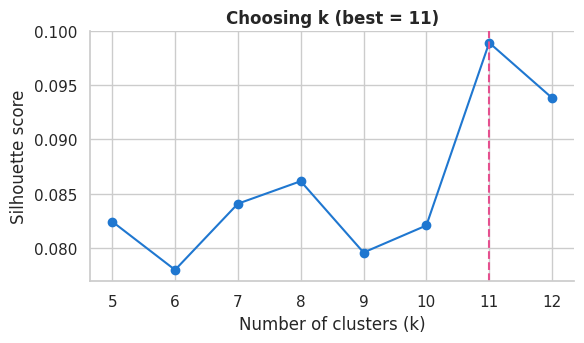

In [21]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer

seg = released[released["Tags"].notna()].copy()
cv = CountVectorizer(tokenizer=lambda s: [t.strip() for t in s.split(",") if t.strip()],
                     lowercase=False, binary=True, max_features=150, token_pattern=None)
X_tags = cv.fit_transform(seg["Tags"])
tag_names = cv.get_feature_names_out()

svd = TruncatedSVD(n_components=25, random_state=RANDOM_STATE)
Z = Normalizer(copy=False).fit_transform(svd.fit_transform(X_tags))
print(f"Segmenting {Z.shape[0]:,} tagged games | SVD variance retained: {svd.explained_variance_ratio_.sum():.1%}")

samp = rng.choice(len(Z), size=8000, replace=False)
scores = {}
for k in range(5, 13):
    labels_k = MiniBatchKMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE).fit_predict(Z)
    scores[k] = silhouette_score(Z[samp], labels_k[samp])
best_k = max(scores, key=scores.get)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(list(scores), list(scores.values()), marker="o", color=BLUE)
ax.axvline(best_k, color=PINK, ls="--")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title(f"Choosing k (best = {best_k})")
plt.tight_layout()
plt.show()

In [22]:
km = MiniBatchKMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(Z)
seg["cluster"] = km.labels_

global_prev = np.asarray(X_tags.mean(axis=0)).ravel()
profiles = []
for c in range(best_k):
    idx = np.where(seg["cluster"].values == c)[0]
    prev = np.asarray(X_tags[idx].mean(axis=0)).ravel()
    lift = np.where(global_prev >= 0.01, prev / np.maximum(global_prev, 1e-9), 0)
    eligible = np.where(prev >= 0.15)[0]
    top = eligible[np.argsort(-lift[eligible])][:3] if len(eligible) else np.argsort(-prev)[:3]
    sub = seg.iloc[idx]
    sub_m = sub[sub["release_year"].between(2014, 2022)]
    profiles.append({
        "cluster": c,
        "segment": " / ".join(tag_names[top]),
        "games": len(idx),
        "share_%": len(idx) / len(seg) * 100,
        "median_price_paid": sub.loc[sub["price"] > 0, "price"].median(),
        "free_share_%": sub["is_free"].mean() * 100,
        "hit_rate_%": sub_m["hit"].mean() * 100,
        "median_reviews": sub["total_reviews"].median(),
        "median_pos_ratio": sub.loc[sub["total_reviews"] >= 50, "pos_ratio"].median(),
    })
profiles = pd.DataFrame(profiles).sort_values("hit_rate_%", ascending=False).reset_index(drop=True)
profiles

,cluster,segment,games,share_%,median_price_paid,free_share_%,hit_rate_%,median_reviews,median_pos_ratio
0,5,Dating Sim / Romance / Visual Novel,6939,8.059,4.790,8.315,48.712,57.000,0.886
1,1,Survival Horror / Thriller / Psychological Horror,7496,8.706,2.990,7.511,41.221,30.000,0.822
2,3,Action RPG / Hack and Slash / Dungeon Crawler,7359,8.547,4.990,10.232,40.591,32.000,0.797
3,2,Turn-Based Strategy / Turn-Based Tactics / Turn-Based,7209,8.373,4.990,9.960,40.575,36.000,0.803
4,0,Management / Sandbox / Immersive Sim,8436,9.798,4.990,11.807,36.038,34.000,0.773
5,7,FPS / Shooter / PvP,9454,10.980,3.990,12.651,30.468,17.000,0.813
6,10,Hidden Object / Puzzle / Point & Click,6463,7.506,2.990,7.798,26.307,19.000,0.843
7,9,2D Platformer / Side Scroller / Bullet Hell,10391,12.069,2.690,6.968,26.235,15.000,0.869
8,6,Relaxing / Logic / Family Friendly,8198,9.521,1.990,5.879,20.972,15.000,0.889
9,8,Indie / Action / Early Access,6948,8.070,2.990,17.415,18.123,23.000,0.729


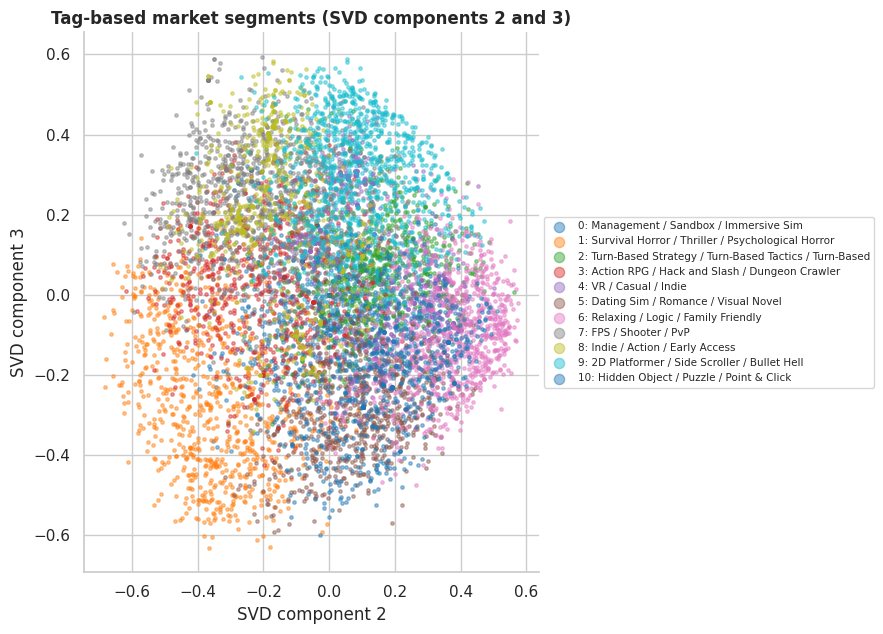

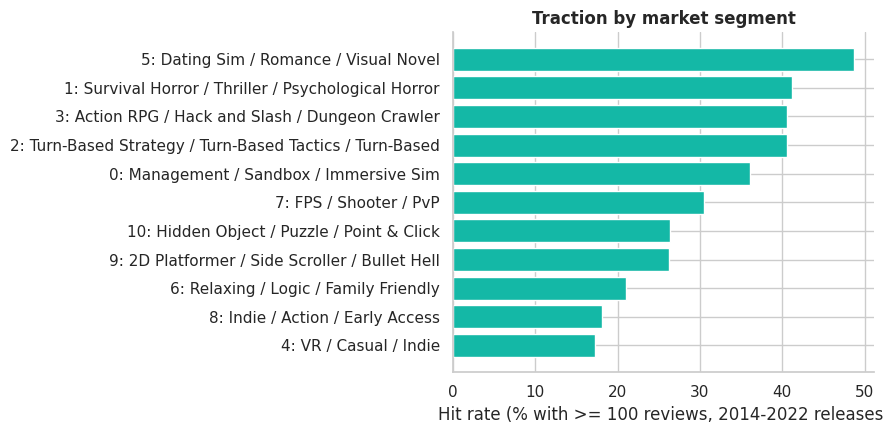

In [23]:
label_map = profiles.set_index("cluster")["segment"].to_dict()
vis = rng.choice(len(Z), size=9000, replace=False)
coords = Z[vis][:, 1:3]

fig, ax = plt.subplots(figsize=(9, 6.5))
cmap = plt.get_cmap("tab10")
for c in range(best_k):
    m = km.labels_[vis] == c
    ax.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.45, color=cmap(c % 10), label=f"{c}: {label_map[c]}")
ax.set_title("Tag-based market segments (SVD components 2 and 3)")
ax.set_xlabel("SVD component 2")
ax.set_ylabel("SVD component 3")
ax.legend(markerscale=3, fontsize=7.5, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
order = profiles.sort_values("hit_rate_%")
ax.barh([f"{r.cluster}: {r.segment}" for r in order.itertuples()], order["hit_rate_%"], color=TEAL)
ax.set_xlabel("Hit rate (% with >= 100 reviews, 2014-2022 releases)")
ax.set_title("Traction by market segment")
plt.tight_layout()
plt.show()

## 9. Key findings, limitations and next steps

In [24]:
best_model = results["PR-AUC"].idxmax()
print("HEADLINE NUMBERS (computed from this run)")
print("-" * 60)
print(f"Titles analysed: {len(df):,} total | {len(released):,} released | data snapshot ~ {SNAPSHOT.date()}")
print(f"Share of released titles with 100+ reviews: {released['hit'].mean():.1%}")
print(f"Concentration: top 1% of games hold {top_share(0.01):.0%} of reviews (Gini {gini:.2f})")
print(f"Free vs paid, probability free game has more reviews: {res.loc[0, 'prob_superiority_free']:.2f}")
print(f"Price bands vs sentiment: epsilon^2 = {eps2:.3f}")
print(f"Mac/Linux support odds ratio for traction: {odds_ratio:.2f}")
best_genre = genre_tests.iloc[0]
worst_genre = genre_tests.iloc[-1]
print(f"Highest-traction genre: {best_genre['genre']} ({best_genre['hit_rate']:.0%}); lowest: {worst_genre['genre']} ({worst_genre['hit_rate']:.0%})")
top_opp = opp.iloc[0]
print(f"Best demand/supply genre (2018-2022): {top_opp['genre']} ({top_opp['demand_to_supply']:.2f}x)")
print(f"Best traction model: {best_model} | ROC-AUC {results.loc[best_model, 'ROC-AUC']:.3f}, lift@10% {results.loc[best_model, 'lift @ top 10%']:.2f}x")
print(f"Sentiment model test R2: {reg_results.loc['Gradient boosting', 'R2']:.3f}")

HEADLINE NUMBERS (computed from this run)
------------------------------------------------------------
Titles analysed: 130,100 total | 126,472 released | data snapshot ~ 2025-12-25
Share of released titles with 100+ reviews: 18.6%
Concentration: top 1% of games hold 75% of reviews (Gini 0.97)
Free vs paid, probability free game has more reviews: 0.42
Price bands vs sentiment: epsilon^2 = 0.027
Mac/Linux support odds ratio for traction: 2.10
Highest-traction genre: Massively Multiplayer (43%); lowest: Education (11%)
Best demand/supply genre (2018-2022): Massively Multiplayer (5.79x)
Best traction model: Gradient boosting (+ tags, post-launch) | ROC-AUC 0.907, lift@10% 4.88x
Sentiment model test R2: -0.015


### Key findings

All figures are from the snapshot analysed here (about 130K titles, data to late December 2025).

**1. The market is crowded and winner-take-most.**
- Yearly releases grew from about 1.6K in 2014 to about 25.6K in 2025. About one third of titles have no reviews and only 18.6% of released titles reach 100+ reviews.
- The top 1% of games hold about 75% of all reviews (Gini 0.97). Discoverability, not production, is the bottleneck.
- The median price of paid games rose from $2.99 (2020) to $4.49 (2025), while free-to-play grew from about 17% to 26% of releases.

**2. Higher price points go with higher traction, but not with better sentiment.**
- Hit rate climbs from 21.5% for $0-2 games to 37.2% for $10-20 and 38.1% for $20+. Free games sit at 23.5%.
- Sentiment barely changes across price bands (epsilon-squared = 0.027). Free games are rated slightly lower: median positive ratio is 0.020 lower (95% CI -0.028 to -0.012).
- Price is best read as a signal of production ambition and budget, not as a lever that causes traction.

**3. Platform reach and localization are strong correlates of traction.**
- 37.5% of games with Mac or Linux support reach 100+ reviews versus 22.2% of Windows-only games (odds ratio 2.10, 95% CI 2.02-2.18).
- In the traction model, the number of supported languages is the single most important launch-time feature (see the importance chart and table in 8.1).
- Both are associations, confounded with studio size and funding. They are good indicators of a serious release, not guaranteed fixes.

**4. Genre matters, and some popular genres are oversupplied.**
- Highest hit rates: Massively Multiplayer (43%), Free To Play (35%), RPG (34%). Lowest: Casual (20%), Early Access (18%), Education (11%). The mature-cohort average is 26%.
- Racing, Sports and Utilities do not differ significantly from the rest after false-discovery correction.
- In the 2018-2022 opportunity map, Casual is 43% of releases but only 18% of reviews (0.43x), and Indie is 0.66x. Action (1.63x), RPG (1.48x) and Adventure (1.19x) earn more attention than their share of releases.
- Massively Multiplayer scores 5.8x, but that is driven by a handful of mega-titles (median 35 reviews), so treat it as a high-variance niche.

**5. Launch timing has a small but real effect.** Hit rate peaks in spring (about 28% for April releases) and falls toward year-end (about 22% for December). The effect is statistically significant but small (Cramer's V = 0.038).

**6. Traction is predictable from launch metadata; sentiment is not.**
- Gradient boosting on launch-time features reaches ROC-AUC 0.841 and PR-AUC 0.569 against a 0.154 base rate. The top-scored 10% of games contain about 4.2x the base rate of hits. The logistic baseline scores 0.814.
- Adding post-launch tags lifts ROC-AUC to 0.907, an upper bound that is partly leaky.
- Sentiment is essentially unpredictable from store metadata: the best model cuts mean absolute error from 0.125 to 0.112, but R-squared is about zero. Part of the gap is a shift in average sentiment between the train era (0.758) and test era (0.813).

**7. Tag-based segments differ sharply in traction.**
- Eleven segments emerge. Dating Sim / Romance / Visual Novel has the highest hit rate (about 49%), followed by Survival Horror, Action RPG and Turn-Based Strategy (about 41% each).
- VR / Casual / Indie (17%) and Indie / Action / Early Access (18%) are the weakest.
- Silhouette scores are low (about 0.10), so segments are overlapping themes rather than clean groups.

### What this means in practice

- **For studios:** budget for localization and a clear store presence, avoid the $0-2 band unless volume is the strategy, and treat Casual and generic Indie positioning as crowded.
- **For publishers and investors:** attention is extremely concentrated, so portfolio returns depend on a few outliers. Genre and segment hit rates give a defensible base rate for screening.
- **For analysts:** the traction model is useful for ranking and screening, not for forecasting individual outcomes.

### Limitations

- **Review counts are a proxy for sales.** They omit revenue, marketing spend, team size and platform featuring, all of which drive real outcomes.
- **Right-censoring.** Newer games have had less time to collect reviews. The mature cohort and the time-based split reduce this bias but do not remove it.
- **Associations, not causes.** Platform support, price band and genre effects are confounded with studio size and budget. Treat them as signals to investigate.
- **Tags post-date launch.** They are community-assigned and partly reflect success, so the tag-based ablation and the segmentation are descriptive rather than predictive of an unreleased game.
- **Approximate snapshot date.** The snapshot is inferred from the latest reviewed release date, not recorded in the file.
- **Prices are in USD** and may reflect sales or conversions for some rows.

### Next steps

- Add revenue estimates (for example from owner-range midpoints and price) and compare against review-based traction.
- Fit a survival or count model for review accumulation to handle censoring explicitly.
- Add text features from `About the game` (TF-IDF or embeddings) to the traction model.
- Track the same metrics across dataset refreshes to monitor genre saturation over time.